### Revision of Python Intermediate level and Above.

In [1]:
class SimpleModel:
    def __init__(self, model_name, framework):
        # Attributes: Data stored in the object
        self.model_name = model_name
        self.framework = framework

    def get_info(self):
        # Method: Logic performed by the object
        return f"Model: {self.model_name} built with {self.framework}"

# Implementation
my_model = SimpleModel("Iris-Classifier", "Scikit-Learn")
print(my_model.get_info())

Model: Iris-Classifier built with Scikit-Learn


In [2]:
from typing import List, Dict

class ChatSession:
    def __init__(self, model_id: str):
        self.model_id: str = model_id
        # State: Keeping track of the conversation
        self.history: List[Dict[str, str]] = [] 

    def add_message(self, role: str, content: str) -> None:
        self.history.append({"role": role, "content": content})

    def get_session_summary(self) -> str:
        return f"Session using {self.model_id} with {len(self.history)} messages."

# Implementation
chat = ChatSession("gpt-4o")
chat.add_message("user", "What is MLOps?")
chat.add_message("assistant", "MLOps is DevOps for Machine Learning.")
print(chat.get_session_summary())
chat.history

Session using gpt-4o with 2 messages.


[{'role': 'user', 'content': 'What is MLOps?'},
 {'role': 'assistant', 'content': 'MLOps is DevOps for Machine Learning.'}]

In [3]:
import time
import uuid

class ProductionLLM:
    def __init__(self, registry_uri: str, model_version: str):
        self.registry_uri = registry_uri
        self.version = model_version
        self.deployment_id = str(uuid.uuid4())
        self.__is_authenticated = False # Encapsulation: Private attribute

    def __authenticate(self):
        # Private method for internal logic only
        print(f"Connecting to {self.registry_uri}...")
        self.__is_authenticated = True

    def predict(self, input_data: str):
        if not self.__is_authenticated:
            self.__authenticate()
        
        # Professional models include telemetry (timing/logging)
        start_time = time.perf_counter()
        
        # Simulate model inference
        result = f"Inference result for version {self.version}"
        
        latency = time.perf_counter() - start_time
        self._log_metrics(latency) # Internal logging
        return result

    def _log_metrics(self, latency: float):
        # In prod, this would send data to Grafana or Prometheus
        print(f"[METRIC] Deployment: {self.deployment_id} | Latency: {latency:.4f}s")

# Implementation
llm_service = ProductionLLM("https://mlflow.company.com", "v2.1.0")
output = llm_service.predict("Analyze this log file.")
print(output)

Connecting to https://mlflow.company.com...
[METRIC] Deployment: 262af9e1-f2ac-4d5c-9560-0e34ae53332a | Latency: 0.0000s
Inference result for version v2.1.0


### Inheritence, Polymorphism, Encapsulation, Abstraction

In [4]:
#----- Inheritence ----#
class BaseModel:
    def __init__(self, name):
        self.name = name
        self.type = "AI Model"

class LLM(BaseModel):
    def generate(self, prompt):
        return f"[{self.name}] generating: {prompt}"

# Implementation
my_llm = LLM("GPT-4o")
print(my_llm.type) # Inherited from BaseModel
print(my_llm.generate("Hello"))

AI Model
[GPT-4o] generating: Hello


In [5]:
class ModelProvider:
    def __init__(self, api_key: str):
        self.__api_key = api_key  # ENCAPSULATION: Double underscore makes it private

    def get_key_prefix(self):
        return self.__api_key[:4] + "****"

    def execute(self, task: str):
        pass # To be overridden

class OpenAI(ModelProvider):
    def execute(self, task: str): # POLYMORPHISM: Different logic, same method name
        return f"OpenAI processing: {task}"

class Anthropic(ModelProvider):
    def execute(self, task: str): # POLYMORPHISM
        return f"Claude processing: {task}"

# Usage
def run_pipeline(provider: ModelProvider, task: str):
    print(provider.execute(task)) # The pipeline doesn't care which provider it is

run_pipeline(OpenAI("sk-123"), "Summarize text")

OpenAI processing: Summarize text


In [6]:
from abc import ABC, abstractmethod

# ABSTRACTION: Defining the contract
class LLMService(ABC):
    @abstractmethod
    def load_weights(self):
        """Must be implemented by any production model class"""
        pass

    @abstractmethod
    def infer(self, payload: dict) -> dict:
        """Standard input/output format for all models in the company"""
        pass

class LlamaProduction(LLMService):
    def load_weights(self):
        print("Loading 70B parameters from S3...")

    def infer(self, payload: dict) -> dict:
        # Complex logic hidden from the user
        return {"status": 200, "output": "Llama response"}

# Implementation
# model = LLMService() # This would throw an error! You cannot instantiate an abstract class.
prod_model = LlamaProduction()
prod_model.load_weights()
print(prod_model.infer({"prompt": "Explain LLMOps"}))

Loading 70B parameters from S3...
{'status': 200, 'output': 'Llama response'}


### Decorators, Class methods, static methods

In [7]:
class SimpleModel:
    @staticmethod
    def validate_input(data):
        # A simple helper that doesn't need 'self'
        return isinstance(data, str)

    @classmethod
    def create_basic(cls):
        # A factory method to create a default version
        return cls(name="Default-Model")

    def __init__(self, name):
        self.name = name

# Implementation
is_valid = SimpleModel.validate_input("Hello") # Static call
model = SimpleModel.create_basic()  # Class call
print(is_valid)
model

True


In [8]:
import time

# A Decorator to measure LLM Latency
def time_it(func):
    def wrapper(*args, **kwargs):
        start = time.perf_counter()
        result = func(*args, **kwargs)
        end = time.perf_counter()
        print(f"Inference Latency: {end - start:.4f}s")
        return result
    return wrapper

class LLMHandler:
    def __init__(self, version):
        self.version = version

    @classmethod
    def from_version(cls, version_num: int):
        # Factory: Creates a specific model based on version
        return cls(f"gpt-{version_num}-turbo")

    @time_it # Applying the decorator
    def generate(self, prompt):
        time.sleep(0.5) # Simulate API delay
        return f"Response from {self.version}"

# Implementation
llm = LLMHandler.from_version(4)
print(llm.generate("What is LLMOps?"))

Inference Latency: 0.5003s
Response from gpt-4-turbo


In [9]:
def my_decorator(func):
    def wrapper():
        print("Before function")
        func()
        print("After function")
    return wrapper

@my_decorator
def hello():
    print("Hello World")

hello()


Before function
Hello World
After function


In [10]:
def log(func):
    def wrapper(*args, **kwargs):
        print(f"Calling {func.__name__}")
        return func(*args, **kwargs)
    return wrapper

@log
def add(a, b):
    return a + b

print(add(3, 4))


Calling add
7


In [11]:
import time

def track_time(func):
    def wrapper(*args, **kwargs):
        start = time.time()
        result = func(*args, **kwargs)
        print(f"{func.__name__} took {time.time()-start:.2f}s")
        return result
    return wrapper

@track_time
def train_model():
    time.sleep(2)

train_model()


train_model took 2.00s


In [12]:
class Student:
    college = "ABC"

    @classmethod
    def change_college(cls, name):
        cls.college = name

Student.change_college("IIT")
print(Student.college)


IIT


In [13]:
class Model:
    def __init__(self, name):
        self.name = name

    @classmethod
    def from_config(cls, config):
        return cls(config["name"])

model = Model.from_config({"name": "XGBoost"})
model


In [14]:
class ModelRegistry:
    registry = {}

    @classmethod
    def register(cls, name, model):
        cls.registry[name] = model

ModelRegistry.register("v1", "LinearModel")



In [15]:
class Math:
    @staticmethod
    def add(a, b):
        return a + b

print(Math.add(2, 3))


5


In [16]:
class DataUtils:
    @staticmethod
    def normalize(x):
        return (x - min(x)) / (max(x) - min(x))


In [17]:
import time
import functools
import logging

# ---------- LOGGING CONFIG ----------
logging.basicConfig(
    level=logging.INFO,
    format="%(levelname)s | %(message)s"
)

# ---------- DECORATOR ----------
def monitor(func):
    """
    Decorator to monitor execution time and errors
    """
    @functools.wraps(func)
    def wrapper(*args, **kwargs):
        start_time = time.time()
        try:
            logging.info(f"Started: {func.__name__}")
            result = func(*args, **kwargs)
            return result
        except Exception as e:
            logging.error(f"Error in {func.__name__}: {e}")
            raise
        finally:
            elapsed = time.time() - start_time
            logging.info(f"Finished: {func.__name__} in {elapsed:.4f}s")
    return wrapper


# ---------- LLM SERVICE ----------
class LLMService:
    service_version = "1.0.0"

    def __init__(self, model_name: str):
        self.model_name = model_name

    @classmethod
    def from_config(cls, config: dict):
        """
        Factory method
        """
        if "model_name" not in config:
            raise ValueError("config must contain 'model_name'")
        return cls(model_name=config["model_name"])

    @staticmethod
    def preprocess(prompt: str) -> str:
        return prompt.strip().lower()

    @monitor
    def generate(self, prompt: str) -> str:
        processed_prompt = self.preprocess(prompt)
        response = f"[{self.model_name}] response to: '{processed_prompt}'"
        return response


# ---------- STEP 6: USAGE ----------
if __name__ == "__main__":
    config = {
        "model_name": "gpt-llama-7b"
    }

    llm = LLMService.from_config(config)

    output = llm.generate("  Explain Decorators in Python  ")
    print(output)


INFO | Started: generate
INFO | Finished: generate in 0.0010s


[gpt-llama-7b] response to: 'explain decorators in python'


In [18]:
import random

# PROFESSIONAL: Retry Decorator
def retry_on_failure(retries=3):
    def decorator(func):
        def wrapper(*args, **kwargs):
            for i in range(retries):
                try:
                    return func(*args, **kwargs)
                except Exception as e:
                    print(f"Attempt {i+1} failed. Retrying...")
                    if i == retries - 1: raise e
        return wrapper
    return decorator

class ProductionInference:
    @staticmethod
    def preprocess(text: str) -> str:
        # Professional: Cleaning input before it hits the expensive LLM
        return text.strip().replace("\n", " ")

    @retry_on_failure(retries=2)
    def call_api(self, cleaned_text):
        if random.random() < 0.5: # Simulate 50% failure rate
            raise ConnectionError("API Timeout")
        return f"Success: {cleaned_text}"

# Implementation
service = ProductionInference()
input_data = "   Hello \n World   "
ready_data = ProductionInference.preprocess(input_data)
print(service.call_api(ready_data))

Attempt 1 failed. Retrying...
Success: Hello   World


#### Magic/Dunder methods.

In [19]:
class SimpleModel:
    def __init__(self, name):
        self.name = name

    def __str__(self):
        # Professional: Clean string for users
        return f"Model: {self.name}"

    def __repr__(self):
        # Professional: Detailed string for developers/logs
        return f"SimpleModel(name='{self.name}')"

# Implementation
model = SimpleModel("Sentiment-Analyzer")
print(str(model))  # Output: Model: Sentiment-Analyzer
print(repr(model)) # Output: SimpleModel(name='Sentiment-Analyzer')

Model: Sentiment-Analyzer
SimpleModel(name='Sentiment-Analyzer')


In [20]:
class InferenceEngine:
    def __init__(self, model_path: str):
        self.model_path = model_path
        print(f"Loading weights from {self.model_path}...")

    def __call__(self, input_text: str):
        # This makes the object callable: engine("hello")
        return f"Processed: {input_text} using {self.model_path}"

# Implementation
engine = InferenceEngine("s3://models/llama-3-v1")
# Instead of engine.predict("Hi"), we do:
response = engine("Hi") 
print(response)

Loading weights from s3://models/llama-3-v1...
Processed: Hi using s3://models/llama-3-v1


In [21]:
class LLMDataset:
    def __init__(self, data_list: list):
        self.data = data_list

    def __len__(self):
        # Allows use of len(dataset)
        return len(self.data)

    def __getitem__(self, index):
        # Allows use of dataset[0] or for loops
        sample = self.data[index]
        return {"input": sample, "label": "processed"}

    def __enter__(self):
        # Context Manager: Logic when entering 'with' block
        print("Opening connection to Data Lake...")
        return self

    def __exit__(self, exc_type, exc_val, exc_tb):
        # Context Manager: Logic when exiting 'with' block
        print("Closing connection to Data Lake...")

# Implementation
raw_data = ["What is AI?", "How does MLOps work?"]
with LLMDataset(raw_data) as ds:
    print(f"Dataset Size: {len(ds)}")
    print(f"First Item: {ds[0]}")

Opening connection to Data Lake...
Dataset Size: 2
First Item: {'input': 'What is AI?', 'label': 'processed'}
Closing connection to Data Lake...


### Reading and writing files

In [22]:

# Writing a list of prompts to a file
prompts = ["Explain Quantum Physics", "Write a poem about MLOps"]

with open("prompts.txt", "w") as f:
    for p in prompts:
        f.write(p + "\n")

# Reading them back
with open("prompts.txt", "r") as f:
    content = f.read()
    print(content)

Explain Quantum Physics
Write a poem about MLOps



In [23]:
import json

# Writing structured training data (JSONL format)
training_data = [
    {"prompt": "Hi", "completion": "Hello!"},
    {"prompt": "Bye", "completion": "Goodbye!"}
]

with open("dataset.jsonl", "w") as f:
    for entry in training_data:
        # Serialize dict to string and write as a new line
        f.write(json.dumps(entry) + "\n")

# Reading specific fields from JSONL
with open("dataset.jsonl", "r") as f:
    for line in f:
        data = json.loads(line)
        print(f"User said: {data['prompt']}")

User said: Hi
User said: Bye


In [24]:
import pickle
import os

class ModelArtifact:
    def __init__(self, weights, version):
        self.weights = weights
        self.version = version

# Implementation: Saving a model object as a binary file
my_model = ModelArtifact(weights=[0.1, 0.5, -0.2], version="v1.0")

# PROFESSIONAL: Binary Write ('wb')
with open("model_v1.bin", "wb") as f:
    pickle.dump(my_model, f)

# PROFESSIONAL: Checking file size before loading (Observability)
file_size = os.path.getsize("model_v1.bin")
print(f"Loading artifact ({file_size} bytes)...")

# Binary Read ('rb')
with open("model_v1.bin", "rb") as f:
    loaded_model = pickle.load(f)
    print(f"Successfully loaded model version: {loaded_model.version}")

Loading artifact (107 bytes)...
Successfully loaded model version: v1.0


### File Handling methods.

In [25]:
with open("notes.txt", "w+") as f:
    f.write("MLOps Revision")
    
    # .tell() shows we are at the end of the file
    print(f"Current Position: {f.tell()}") 
    
    # .seek(0) moves cursor back to the start
    f.seek(0)
    print(f"Re-reading content: {f.read()}")

Current Position: 14
Re-reading content: MLOps Revision


In [26]:
from pathlib import Path

# INTERMEDIATE: Creating a robust directory structure for model versions
base_path = Path("models") / "llama3" / "v1"

# Create directory if it doesn't exist (equivalent to mkdir -p)
base_path.mkdir(parents=True, exist_ok=True)

model_file = base_path / "weights.bin"

if model_file.exists():
    print(f"Loading weights from: {model_file}")
else:
    print("No weights found. Starting training...")

No weights found. Starting training...


In [33]:
# def resume_processing(file_path, last_position=0):
#     with open(file_path, "r") as f:
#         # PROFESSIONAL: Jump directly to the last processed byte
#         f.seek(last_position)
        
#         # Process the next chunk
#         new_data = f.readline()
        
#         # Save the new position for the next checkpoint
#         current_pos = f.tell()
#         return new_data, current_pos

# # Implementation
# # If we previously stopped at byte 5432...
# data, next_pos = resume_processing("huge_dataset.jsonl", last_position=5432)
# print(f"Resumed at {next_pos}")

### Exception Handling: tryexcept and custom exceptions.

In [34]:
# A simple list of inputs where one is invalid
prompts = ["Tell me a joke", 12345, "What is AI?"]

for p in prompts:
    try:
        # This will fail if p is not a string
        print(f"Processing: {p.lower()}")
    except Exception as e:
        print(f"Skipped an item due to error: {e}")

Processing: tell me a joke
Skipped an item due to error: 'int' object has no attribute 'lower'
Processing: what is ai?


In [35]:
import os

def load_local_model(path: str):
    try:
        if not path.endswith(".bin"):
            raise ValueError("Model must be a .bin file")
        
        # Simulating opening a large file
        print(f"Opening {path}...")
        # f = open(path, 'rb')
        
    except FileNotFoundError:
        print("Error: The model file does not exist at that path.")
    except ValueError as ve:
        print(f"Validation Error: {ve}")
    finally:
        print("Cleanup: Ensuring system resources are stable.")

load_local_model("llama.txt")

Validation Error: Model must be a .bin file
Cleanup: Ensuring system resources are stable.


In [36]:
# PROFESSIONAL: Custom Exception Classes
class LLMError(Exception):
    """Base class for all LLM-related errors."""
    pass

class RateLimitError(LLMError):
    """Raised when the API provider throttles requests."""
    pass

class SafetyFilterError(LLMError):
    """Raised when the model refuses to answer due to safety."""
    pass

def call_primary_llm(prompt):
    # Simulate a 429 Rate Limit error from an API
    raise RateLimitError("OpenAI API: Rate limit reached (429).")

# Implementation: Resilient Pipeline
user_prompt = "Generate a strategy for MLOps."

try:
    response = call_primary_llm(user_prompt)
except RateLimitError as e:
    print(f"PRIMARY FAILED: {e}")
    print("ACTION: Switching to local Llama-3 fallback...")
    # response = call_local_llama(user_prompt)
except SafetyFilterError:
    print("ACTION: Notifying user that the request was blocked.")
except LLMError:
    print("ACTION: General LLM failure. Check system logs.")

PRIMARY FAILED: OpenAI API: Rate limit reached (429).
ACTION: Switching to local Llama-3 fallback...


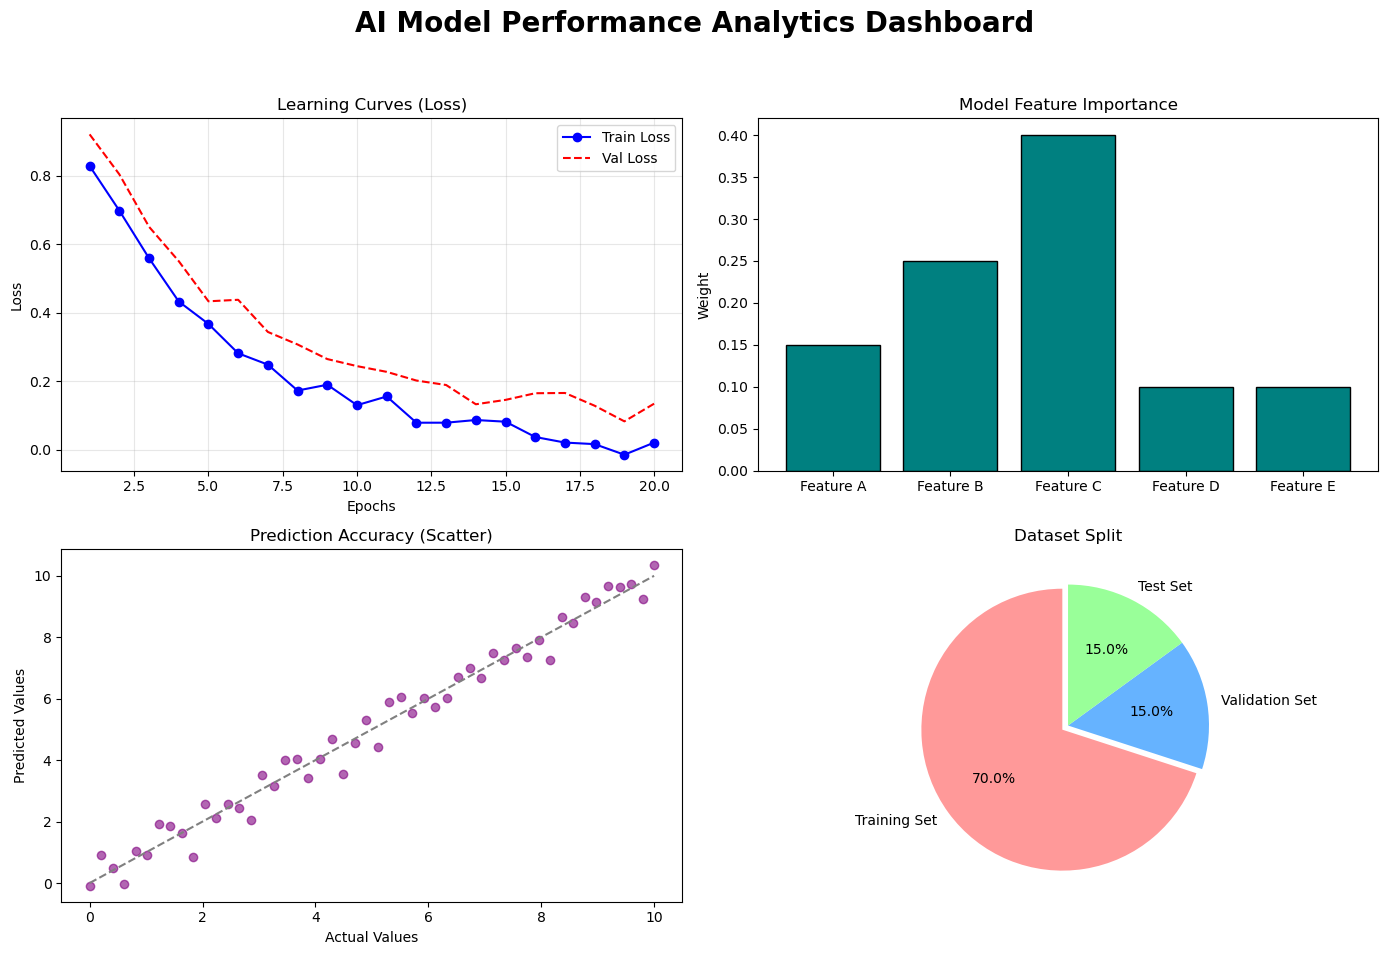

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# --- STEP 1: Data Preparation ---
epochs = np.arange(1, 21)
train_loss = np.exp(-epochs/5) + np.random.normal(0, 0.02, 20)
val_loss = np.exp(-epochs/5) + 0.1 + np.random.normal(0, 0.02, 20)
accuracy = 1 - train_loss
feature_importance = [0.15, 0.25, 0.40, 0.10, 0.10]
features = ['Feature A', 'Feature B', 'Feature C', 'Feature D', 'Feature E']

# --- STEP 2: Creating the Figure & Subplots (2x2 Grid) ---
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
fig.suptitle('AI Model Performance Analytics Dashboard', fontsize=20, fontweight='bold')

# Plot 1: Line Plot (Training vs Validation Loss)
axes[0, 0].plot(epochs, train_loss, label='Train Loss', marker='o', color='blue')
axes[0, 0].plot(epochs, val_loss, label='Val Loss', linestyle='--', color='red')
axes[0, 0].set_title('Learning Curves (Loss)')
axes[0, 0].set_xlabel('Epochs')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Plot 2: Bar Chart (Feature Importance)
axes[0, 1].bar(features, feature_importance, color='teal', edgecolor='black')
axes[0, 1].set_title('Model Feature Importance')
axes[0, 1].set_ylabel('Weight')

# Plot 3: Scatter Plot (Predicted vs Actual - Simulated)
actual = np.linspace(0, 10, 50)
predicted = actual + np.random.normal(0, 0.5, 50)
axes[1, 0].scatter(actual, predicted, alpha=0.6, color='purple')
axes[1, 0].plot([0, 10], [0, 10], color='gray', linestyle='--') # Identity line
axes[1, 0].set_title('Prediction Accuracy (Scatter)')
axes[1, 0].set_xlabel('Actual Values')
axes[1, 0].set_ylabel('Predicted Values')

# Plot 4: Pie Chart (Data Distribution)
labels = ['Training Set', 'Validation Set', 'Test Set']
sizes = [70, 15, 15]
colors = ['#ff9999','#66b3ff','#99ff99']
axes[1, 1].pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90, explode=(0.05, 0, 0))
axes[1, 1].set_title('Dataset Split')

# --- STEP 3: Final Touches ---
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make room for suptitle
plt.show()